# Optimization and hyperparameter tuning

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

## Step 0: Define a dataset

See the dataset specification at this [link](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data', 
                 header=None, index_col=0)

print(f"Loaded the Wisconsin Breast Cancer dataset of size {df.shape}")
df.head()

Loaded the Wisconsin Breast Cancer dataset of size (569, 31)


,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
0,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X = df.loc[:, 2:].values # Numerical features about the mass
y = df.loc[:, 1].values # M for malignant, B for benign

# Encode the categorical labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print(f"Benign masses have label {label_encoder.transform(['B'])[0]}")
print(f"Malignant masses have label {label_encoder.transform(['M'])[0]}")

# Count the number of each class
n_benign = np.sum(y == 0)
n_malignant = np.sum(y == 1)
print(f"There are {n_benign} benign samples and {n_malignant} malignant_samples")

Benign masses have label 0
Malignant masses have label 1
There are 357 benign samples and 212 malignant_samples


Text(0.5, 1.0, 'Feature correlation matrix')

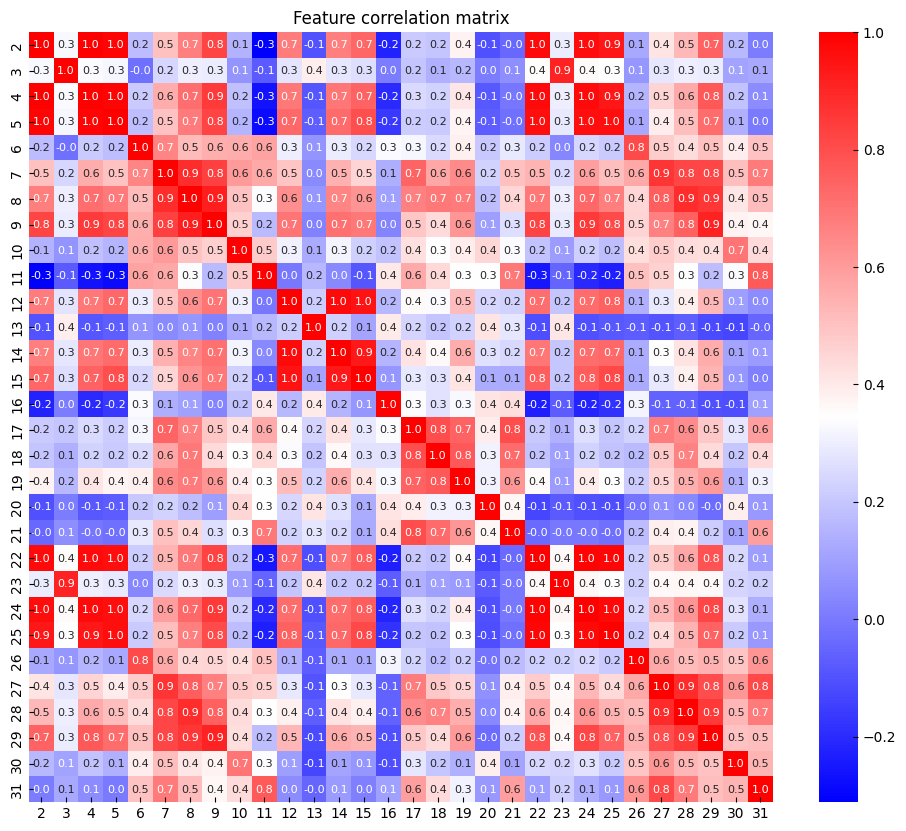

In [4]:
ax = plt.figure(figsize=(12,10)).gca()
sns.heatmap(df.loc[:, 2:].corr(), annot=True, cmap='bwr', fmt='.1f', annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature correlation matrix')

Notice that there are several highly-correlated features! This is important, because if the features contain redundant information, then the model's coefficients could vary wildly even with small changes to the data.

What this means is that a model fit to this data may show large **variance**. 

What can we do about this? Well there are a few options:
- Ignore it (this is the easiest option)
- Remove highly-correlated features
- Dimensionality reduction with e.g. PCA
- Regularization (L1 would sparsify the coefficients, for example)

All of these will affect how well the model generalizes, so we'll start by creating separate train and test sets

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"The training set has size {X_train.shape}")
print(f"The testing set has size {X_test.shape}")

The training set has size (455, 30)
The testing set has size (114, 30)


## Step 1: Define Logistic Regression model

We will include a lot of the machinery from previous lectures, as well as separate training/validation/testing loops

In [87]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin

def cross_entropy(y, y_model, eps=1e-10):
    return -y.dot(np.log(y_model + eps)) - (1-y).dot(np.log(1-y_model + eps))

class LogisticRegressionL1(BaseEstimator, ClassifierMixin):
    """ Gradient descent variant with L1 regularization (since we have so many features)
    """
    def __init__(self, 
                 eta=0.25, 
                 n_epochs=100, 
                 alpha=0.1,
                 random_seed=42):
        self.eta = eta
        self.n_epochs = n_epochs
        self.alpha = alpha
        self.random_seed = random_seed

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """ Fit training data and track training/validation losses """
        validate = X_val is not None and y_val is not None

        # Initialize model weights
        self.rng = np.random.default_rng(seed=self.random_seed)
        self.w_ = self.rng.normal(loc=0, scale=0.01, size=X.shape[1])
        self.b_ = np.float_(0.)

        # Feature scaling
        self.scaler_ = StandardScaler()
        X_train_std = self.scaler_.fit_transform(X_train)
        if validate:
            X_val_std = self.scaler_.transform(X_val)

        # Initialize loss tracking
        self.train_loss_ = []
        if validate:
            self.val_loss_ = []

        # iterate over epochs
        for _ in range(self.n_epochs):
            train_loss = self._train_epoch(X_train_std, y_train)
            self.train_loss_.append(train_loss)

            if validate:
                val_loss = self._val_epoch(X_val_std, y_val)
                self.val_loss_.append(val_loss)

        return self

    def _train_epoch(self, X, y):
        z = self.pre_activation(X)
        pred = self.activation(z)

        diff = y - pred
        self.w_ += self.eta * (diff.dot(X) / X.shape[0] - self.alpha * np.sign(self.w_))
        self.b_ += self.eta * diff.mean()

        loss = cross_entropy(y, pred) + self.alpha * np.sum(np.abs(self.w_))
        return loss / X.shape[0]

    def _val_epoch(self, X, y):
        z = self.pre_activation(X)
        pred = self.activation(z)

        loss = cross_entropy(y, pred) + self.alpha * np.sum(np.abs(self.w_))
        return loss / X.shape[0]

    def pre_activation(self, X):
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))

    def predict_proba(self, X):
        """ Separate function for class probabilities to enable ROC analysis later"""
        X_std = self.scaler_.transform(X)
        z = self.pre_activation(X_std)
        return self.activation(z)

    def predict(self, X):
        y_prob = self.predict_proba(X)
        return np.where(y_prob >= 0.5, 1, 0)

    def score(self, X, y):
        """ Accuracy score of model"""
        return np.mean(self.predict(X) == y)

Training accuracy = 0.938
Testing accuracy = 0.956


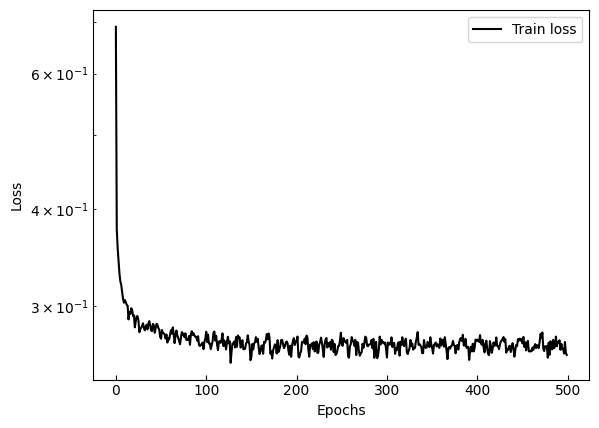

In [99]:
model = LogisticRegressionL1(eta=0.25, alpha=0.1, n_epochs=500)
model.fit(X_train, y_train)

# Score the model on the training set
y_train_pred = model.predict(X_train)
train_accuracy = model.score(X_train, y_train)
print(f"Training accuracy = {train_accuracy:.3f}")

y_test_pred = model.predict(X_test)
test_accuracy = model.score(X_test, y_test)
print(f"Testing accuracy = {test_accuracy:.3f}")


# Plot the loss curves
ax = plt.figure().gca()
ax.plot(model.train_loss_, color='black', label='Train loss')
ax.legend()
ax.set(xlabel='Epochs', ylabel='Loss', yscale='log');

## Plot the decision boundary

We don't have 30-dimensional brains so we'll use PCA to plot the decision boundary in a reduced space

(569, 30)
(186636, 2)


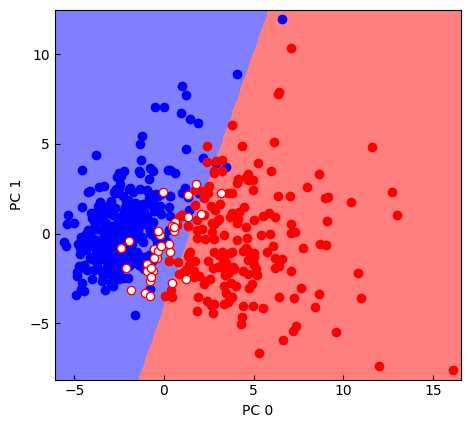

In [100]:
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

def plot_decision_boundary(ax, X, y, model, d=0.05, colors=['blue', 'red']):
    print(X.shape, flush=True)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(model.scaler_.transform(X))

    x1, x2 = np.meshgrid(
        np.arange(X_pca[:, 0].min()-10*d, X_pca[:, 0].max()+10*d, d),
        np.arange(X_pca[:, 1].min()-10*d, X_pca[:, 1].max()+10*d, d),
    )
    grid_pca = np.stack([x1.ravel(), x2.ravel()]).T
    print(grid_pca.shape)

    grid_raw = model.scaler_.inverse_transform(pca.inverse_transform(grid_pca))
    y_model = model.predict(grid_raw)
    y_model = y_model.reshape(x1.shape)

    pred_mask = model.predict(X) == y

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for ii, label in enumerate(np.unique(y)):
        label_mask = y == label
        ax.scatter(X_pca[label_mask & pred_mask, 0], X_pca[label_mask & pred_mask, 1], 
                   facecolor=colors[label], edgecolor=colors[label])
        ax.scatter(X_pca[label_mask & ~pred_mask, 0], X_pca[label_mask & ~pred_mask, 1], 
                   facecolor='white', edgecolor=colors[label])
    return ax

ax = plt.figure().gca()
plot_decision_boundary(ax, X, y, model)
ax.set(xlabel='PC 0', xticks=[-5, 0, 5, 10, 15],
       ylabel='PC 1', yticks=[-5, 0, 5, 10], aspect='equal');

## ROC curve

False positive rate = (# False positives) / (# negative samples)

True positive rate = (# True positives) / (# positive samples)

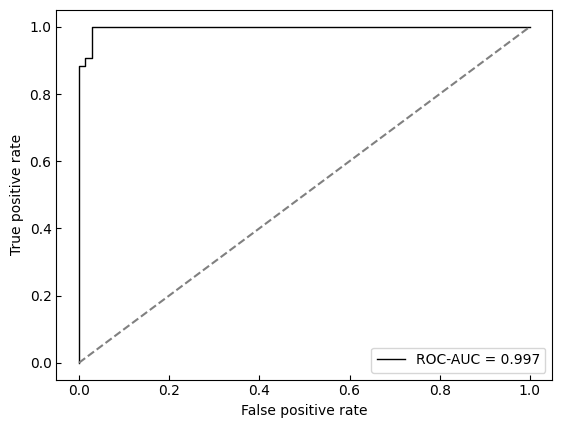

In [101]:
from sklearn.metrics import roc_curve, auc

y_prob_test = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test, pos_label=1)
roc_auc = auc(fpr, tpr)

ax = plt.figure().gca()
ax.plot(fpr, tpr, color='black', lw=1, label=f"ROC-AUC = {roc_auc:.3f}")
ax.plot([0,1], [0,1], color='grey', linestyle='--')
ax.set(xlabel='False positive rate', ylabel='True positive rate')
ax.legend();

## K-fold cross validation

Before, we only used one validation set to estimate performance during training. But this is a partial snapshot. The idea behind cross-validation is you create several distinct train/val splits so that you have a performance estimate over the entire training set. 

Using cross-validation, you can more accurately assess and tune model hyperparameters before applying the model to test data

In [114]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_accuracy = []

model = LogisticRegressionL1(eta=0.25, alpha=0.1, n_epochs=500)

for k, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    model.fit(X_train[train_idx], y_train[train_idx], X_train[val_idx], y_train[val_idx])
    val_accuracy = model.score(X_train[val_idx], y_train[val_idx])
    print(f"Fold {k} validation accuracy = {val_accuracy:.3f}")

    fold_accuracy.append(val_accuracy)

print()
print(f"Cross-validation accuracy = {np.mean(fold_accuracy):.3f} +/- {np.std(fold_accuracy):.3f}")

Fold 0 validation accuracy = 0.978
Fold 1 validation accuracy = 0.935
Fold 2 validation accuracy = 0.935
Fold 3 validation accuracy = 0.935
Fold 4 validation accuracy = 0.913
Fold 5 validation accuracy = 0.911
Fold 6 validation accuracy = 1.000
Fold 7 validation accuracy = 0.933
Fold 8 validation accuracy = 0.889
Fold 9 validation accuracy = 0.933

Cross-validation accuracy = 0.936 +/- 0.030


## Hyperparameter tuning with cross validation

We want to get the training parameters $\alpha,\eta$ that will maximize our generalization accuracy. To do this, we can do a grid search and track the cross-validation accuracy for each parameter combination

In [128]:
from itertools import product

alpha_grid = np.geomspace(1e-4, 1, 5)
eta_grid = np.geomspace(1e-3, 1, 5)

tracking = pd.DataFrame(columns=['alpha', 'eta', 'fold', 'score'])

model = LogisticRegressionL1(n_epochs=500)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for alpha, eta in product(alpha_grid, eta_grid):
    model.alpha = alpha
    model.eta = eta

    for k, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        model.fit(X_train[train_idx], y_train[train_idx], X_train[val_idx], y_train[val_idx])
        val_accuracy = model.score(X_train[val_idx], y_train[val_idx])
        tracking.loc[len(tracking)] = [alpha, eta, k, val_accuracy]

param_df = tracking.groupby(['alpha', 'eta']).agg({'score': 'mean'}).reset_index().sort_values('score', ascending=False)
model.alpha = param_df.iloc[0]['alpha']
model.eta = param_df.iloc[0]['eta']
print(f"The best estimator had parameters (alpha = {model.alpha:.3f}, eta = {model.eta:.3f}) and had a score of {param_df.iloc[0]['score']:.3f}")


model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"This estimator reaches a test accuracy of {test_accuracy:.3f}")

param_df

The best estimator had parameters (alpha = 0.010, eta = 0.032) and had a score of 0.974
This estimator reaches a test accuracy of 0.982


,alpha,eta,score
12,0.0100,0.031623,0.973626
8,0.0010,0.177828,0.973626
2,0.0001,0.031623,0.971429
7,0.0010,0.031623,0.971429
14,0.0100,1.000000,0.969231
3,0.0001,0.177828,0.969231
9,0.0010,1.000000,0.969231
4,0.0001,1.000000,0.969231
13,0.0100,0.177828,0.969231
1,0.0001,0.005623,0.960440


We can automate a lot of this machinery in Scikit-Learn using GridSearchCV

In [104]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
param_grid = {
    'alpha': np.geomspace(1e-4, 1, 5),
    'eta': np.geomspace(1e-3, 1, 5)
}

model = LogisticRegressionL1(eta=0.25, alpha=0.0, n_epochs=500)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = GridSearchCV(estimator=model, param_grid=param_grid, cv=cv)
clf.fit(X_train, y_train)

print(f"The best estimator had parameters {clf.best_params_} and had a score of {clf.best_score_:.3f}")
test_accuracy = clf.best_estimator_.score(X_test, y_test)
print(f"This estimator reaches a test accuracy of {test_accuracy:.3f}")

The best estimator had parameters {'alpha': 0.01, 'eta': 0.03162277660168379} and had a score of 0.974
This estimator reaches a test accuracy of 0.982


In [105]:
clf.cv_results_

{'mean_fit_time': array([0.03926501, 0.03801579, 0.06788316, 0.02962365, 0.02493105,
        0.03055382, 0.03481555, 0.02961264, 0.03695464, 0.03104901,
        0.02974062, 0.02706723, 0.02409325, 0.03991995, 0.03492761,
        0.03148532, 0.03426905, 0.03437819, 0.0347908 , 0.02777061,
        0.03387251, 0.03455997, 0.04363942, 0.03733521, 0.03834434]),
 'std_fit_time': array([0.01485383, 0.00870861, 0.05759627, 0.00401533, 0.00330144,
        0.00682764, 0.00789532, 0.00620097, 0.00763174, 0.00597001,
        0.00241396, 0.00402241, 0.00197421, 0.01085355, 0.00593907,
        0.00453127, 0.00531318, 0.00587404, 0.00514014, 0.00350242,
        0.00435045, 0.00880535, 0.01356762, 0.00999986, 0.00555859]),
 'mean_score_time': array([0.00015755, 0.00014958, 0.00016537, 0.00025363, 0.00010653,
        0.00013623, 0.00020027, 0.00010915, 0.00016513, 0.0001411 ,
        0.00011215, 0.00013633, 0.000141  , 0.00023808, 0.00012574,
        0.00015574, 0.00018659, 0.00021858, 0.00022373, 0.00